# Semivariogram analysis: how far apart do NDVI sample patches need to be?

Estimates the spatial autocorrelation range of NDVI within Sisal's mangroves from an exported raster, so the minimum spacing between your 90x90 m sample patches is based on evidence rather than a guess.

**Concept:** the semivariogram measures how different two pixels' NDVI values tend to be, as a function of the distance between them. Close together, pixels are similar (low semivariance); far apart, they become unrelated (semivariance flattens out at the "sill"). The distance where it flattens is the "range" - beyond that distance, two points carry independent information about mangrove condition.

Expects a single-band GeoTIFF (the NDVI composite exported from the GEE script's semivariogram section), in a projected metric CRS (meters), with non-mangrove pixels masked out.

Run the cells top to bottom. The synthetic validation section runs regardless of whether you have the real raster yet, so you can see the method actually works before trusting it on real data.

In [33]:
%matplotlib inline
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skgstat import Variogram

## Config

In [34]:
CONFIG = {
    "raster_path": "Sisal_NDVI_composite_for_variogram.tif",
    "n_sample_points": 4000,   # subsampled from all valid pixels - pairwise distance
                                # computation is O(n^2), so this keeps it tractable
                                # while still giving ~4.5 million pairs
    "n_lags": 25,               # number of distance bins in the empirical semivariogram
    # "maxlag": None,             # None = auto (skgstat default: MAX pairwise distance);
                                 # set a number (meters) to cap it if the AOI is large
                                 # and you only care about short-range structure
    "maxlag": 6000,            # meters - roughly half your AOI's max extent
    "models": ["spherical", "exponential", "gaussian"],
    # "models": ["spherical"],
    "random_seed": 0,
}

## 1. Load raster and extract sample points

In [26]:
def load_raster_samples(path, n_sample_points, seed=0):
    """
    Reads a single-band raster, extracts (x, y) coordinates in the raster's
    native CRS units (expected to be meters - e.g. UTM) and the pixel value,
    for valid (non-nodata, non-nan) pixels only, then randomly subsamples.
    """
    with rasterio.open(path) as src:
        band = src.read(1).astype(float)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs

    if nodata is not None:
        band[band == nodata] = np.nan

    rows, cols = np.where(~np.isnan(band))
    values = band[rows, cols]

    xs, ys = rasterio.transform.xy(transform, rows, cols)
    coords = np.column_stack([xs, ys])

    rng = np.random.default_rng(seed)
    n_valid = len(values)
    if n_valid > n_sample_points:
        idx = rng.choice(n_valid, size=n_sample_points, replace=False)
        coords, values = coords[idx], values[idx]

    print(f"Loaded {n_valid} valid pixels, using {len(values)} for the variogram "
          f"(CRS: {crs}).")
    if crs is not None and crs.is_geographic:
        print("WARNING: raster CRS is geographic (degrees), not projected (meters). "
              "Distances below will be in degrees, not meters - re-export with a "
              "projected CRS (e.g. UTM) for a meaningful spacing recommendation.")

    return coords, values

## 2. Fit semivariogram models and compare

In [27]:
def fit_variograms(coords, values, config):
    """Fits each candidate model, returns a dict of {model_name: Variogram},
    sorted by fit quality (RMSE) so the best-fitting model is first."""
    results = {}
    for model in config["models"]:
        V = Variogram(
            coords, values,
            n_lags=config["n_lags"],
            maxlag=config["maxlag"],
            model=model,
        )
        results[model] = V

    ranked = sorted(results.items(), key=lambda kv: kv[1].rmse)
    print("\nModel fit comparison (lower RMSE = better fit):")
    for name, V in ranked:
        d = V.describe()
        print(f"  {name:12s} range={d['effective_range']:7.1f} m   "
              f"sill={d['sill']:.4f}   nugget={d['nugget']:.4f}   rmse={V.rmse:.4f}")

    return dict(ranked)


def plot_variogram(V, model_name, output_path=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(V.bins, V.experimental, color="tab:blue", label="empirical", zorder=3)

    d = V.describe()
    lags = np.linspace(0, V.bins[-1], 200)
    fitted = V.fitted_model(lags)
    ax.plot(lags, fitted, color="black", linestyle="--", label=f"{model_name} fit")

    ax.axvline(d["effective_range"], color="red", linestyle=":",
               label=f"range = {d['effective_range']:.0f} m")
    ax.axhline(d["sill"], color="gray", linewidth=0.8)

    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Semivariance")
    ax.set_title(f"NDVI semivariogram ({model_name} model)")
    ax.legend()
    fig.tight_layout()
    plt.show()
    if output_path:
        fig.savefig(output_path, dpi=120)
    plt.close(fig)


def recommend_spacing(V, patch_size):
    """Turns a fitted variogram's range into a concrete spacing recommendation,
    combined with the hard non-overlap constraint from patch geometry."""
    effective_range = V.describe()["effective_range"]
    non_overlap_min = patch_size * np.sqrt(2)  # worst-case diagonal offset
    recommended = max(effective_range, non_overlap_min)

    print(f"\nPatch non-overlap minimum (90x90 m patches): {non_overlap_min:.0f} m")
    print(f"Empirical spatial autocorrelation range:       {effective_range:.0f} m")
    print(f"--> Recommended minimum spacing: {recommended:.0f} m "
          f"({'autocorrelation range' if recommended == effective_range else 'non-overlap constraint'} is binding)")
    return recommended

## 3. Synthetic validation

Runs the pipeline on fake landscapes with increasing spatial smoothness and checks the fitted range increases monotonically. This is the right bar for "does this method work" - not exact number recovery (Gaussian smoothing doesn't map 1:1 onto the range convention used by these variogram models), but a monotonic, sensible response to genuine differences in spatial structure.

Does fitted range track true spatial structure?


Model fit comparison (lower RMSE = better fit):
  exponential  range=  359.4 m   sill=0.0066   nugget=0.0000   rmse=0.0007
  gaussian     range=  316.7 m   sill=0.0066   nugget=0.0000   rmse=0.0007
  spherical    range=  327.8 m   sill=0.0066   nugget=0.0000   rmse=0.0007
  true smoothing bandwidth   30 m  ->  fitted range   359.4 m  (exponential)

Model fit comparison (lower RMSE = better fit):
  gaussian     range=  487.2 m   sill=0.0059   nugget=0.0000   rmse=0.0009
  spherical    range=  531.4 m   sill=0.0059   nugget=0.0000   rmse=0.0009
  exponential  range=  604.5 m   sill=0.0059   nugget=0.0000   rmse=0.0009
  true smoothing bandwidth   90 m  ->  fitted range   487.2 m  (gaussian)

Model fit comparison (lower RMSE = better fit):
  gaussian     range=  888.5 m   sill=0.0061   nugget=0.0000   rmse=0.0011
  spherical    range=  978.5 m   sill=0.0061   nugget=0.0000   rmse=0.0011
  exponential  range= 1219.4 m   sill=0.0062   nugget

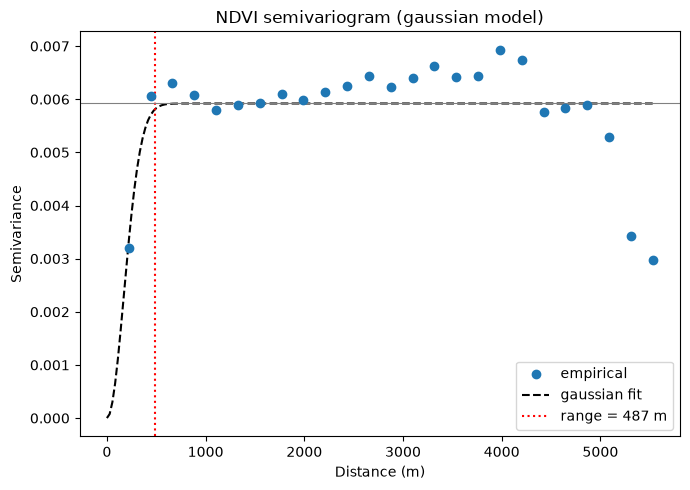

True

In [22]:
def simulate_correlated_field(size_px=400, pixel_size=10, sigma_m=90, seed=0):
    """Builds a fake NDVI-like raster with spatial structure, by Gaussian-
    smoothing white noise with bandwidth sigma_m (meters)."""
    rng = np.random.default_rng(seed)
    white_noise = rng.normal(size=(size_px, size_px))
    sigma_px = sigma_m / pixel_size
    field = gaussian_filter(white_noise, sigma=sigma_px, mode="wrap")
    field = (field - field.mean()) / field.std()
    field = 0.7 + 0.08 * field  # centered around a plausible healthy-mangrove NDVI

    rows, cols = np.meshgrid(np.arange(size_px), np.arange(size_px), indexing="ij")
    xs = cols.ravel() * pixel_size
    ys = rows.ravel() * pixel_size
    coords = np.column_stack([xs, ys])
    values = field.ravel()
    return coords, values


def run_synthetic_validation(config):
    print("Does fitted range track true spatial structure?\n")
    test_bandwidths_m = [30, 90, 200]
    rng = np.random.default_rng(config["random_seed"])
    recovered_ranges = []
    best_V_mid, best_model_mid = None, None

    for sigma_m in test_bandwidths_m:
        coords, values = simulate_correlated_field(sigma_m=sigma_m, seed=config["random_seed"])
        n_valid = len(values)
        idx = rng.choice(n_valid, size=min(config["n_sample_points"], n_valid), replace=False)
        coords, values = coords[idx], values[idx]

        fitted = fit_variograms(coords, values, config)
        best_model, best_V = next(iter(fitted.items()))
        effective_range = best_V.describe()["effective_range"]
        recovered_ranges.append(effective_range)
        print(f"  true smoothing bandwidth {sigma_m:4d} m  ->  fitted range {effective_range:7.1f} m  ({best_model})")

        if sigma_m == test_bandwidths_m[len(test_bandwidths_m) // 2]:
            best_V_mid, best_model_mid = best_V, best_model

    is_monotonic = all(a < b for a, b in zip(recovered_ranges, recovered_ranges[1:]))
    if is_monotonic:
        print("\nPASS: fitted range increases monotonically with true spatial smoothness.")
    else:
        print("\nWARNING: fitted range did NOT increase monotonically - investigate before trusting real-data results.")

    plot_variogram(best_V_mid, best_model_mid)
    return is_monotonic


run_synthetic_validation(CONFIG)

## 4. Run on your real exported raster

Point `CONFIG['raster_path']` at the downloaded GeoTIFF from the GEE script's semivariogram export section. If it's not found yet, this cell just reports that and stops - re-run once you have the file.

Loaded 706659 valid pixels, using 4000 for the variogram (CRS: EPSG:32615).

Model fit comparison (lower RMSE = better fit):
  exponential  range= 1165.1 m   sill=0.0181   nugget=0.0000   rmse=0.0010
  spherical    range=  869.2 m   sill=0.0178   nugget=0.0000   rmse=0.0013
  gaussian     range=  647.7 m   sill=0.0177   nugget=0.0000   rmse=0.0014


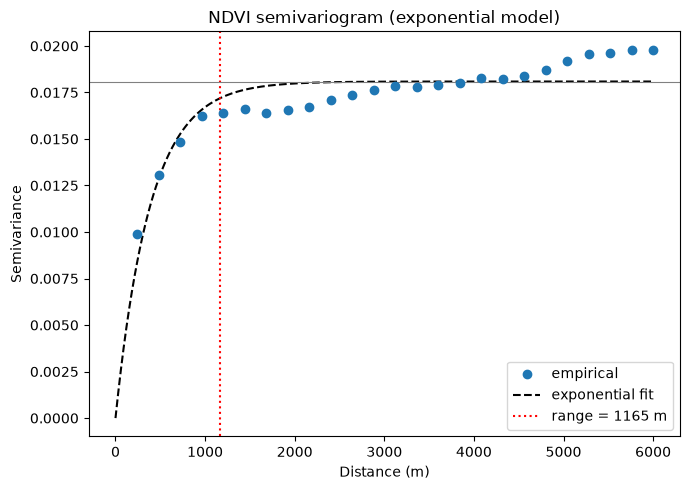


Patch non-overlap minimum (90x90 m patches): 85 m
Empirical spatial autocorrelation range:       1165 m
--> Recommended minimum spacing: 1165 m (autocorrelation range is binding)


In [35]:
if not os.path.exists(CONFIG["raster_path"]):
    print(f"'{CONFIG['raster_path']}' not found.")
    print("Export it from the GEE script's semivariogram section, download it, "
          "and re-run this cell once it's in this folder.")
else:
    coords, values = load_raster_samples(
        CONFIG["raster_path"], CONFIG["n_sample_points"], CONFIG["random_seed"]
    )
    fitted = fit_variograms(coords, values, CONFIG)
    best_model, best_V = next(iter(fitted.items()))
    plot_variogram(best_V, best_model)
    recommend_spacing(best_V, patch_size=60)

In [24]:
print(CONFIG["maxlag"])

6000
